Accompanying Worksheets to Notes in [Introduction to Computational Physics](https://www.amazon.com/Introduction-Computational-Physics-Differential-Simulations/dp/B0GJD4DNNY).

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

# Worksheet 14: Pendulum and Runge-Kutta Method

- Solve initial value problem ODE with `solve_ivp`;
- Convert a 2nd-order equation into two 1st-order ODEs;
- Implement RK4; compare with Euler with  same $dt$;
- Energy conservation check for the undamped pendulum;
- Phase portrait; i.e. graph $\theta$ vs. $\omega$.
</div>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp, quad

The general procedure to solve an ODE begins with defining the differential equation.  If it is a second-order equation, you will need to introduce additional variables and split it into multiple first-order differential equations.

## ODE method

1.  Reduce ODE to multiple first-order ODEs and define vector $\vec{y}$
2.  Write a function `def f(t,y):` returning $dy/dt$ as a vector
3.  Set initial conditions $\vec{y}_0$
4.  Define step size and time span with array $t$
5.  Call `sol = solve_ivp(f, (t0,tf), y0)`
6.  Graph solutions (`t`, `sol[:,j]`)  

## Second Order Differential Equations

The forward Euler algorithm only solves first-order differential equations. However, higher order differential equations can be converted into multiple first-order differential equations.

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">


## Task 1a: Mass-Spring System with solve_ivp

Using Newton's law, we can write an equation of motion:

$$
m \frac{d^2x}{dt^2} = - k x
$$

### Apply the 6 steps: 

a.  Reduce ODE to multiple first-order ODEs and define vector $\vec{y}$
b.  Write a function `def f(t,y):` returning $dy/dt$ as a vector
c.  Set initial conditions $\vec{y}_0$ (set amplitude to 14cm and speed to 0m/s at t=0s)
d.  Define time span starting at $t_0$ and ending at $t_f$
e.  Call `sol = solve_ivp(f, (t0,tf), y0)`
f.  Graph solutions (`t`, `sol[:,j]`)  
</div>

In [2]:
# your code: # Reduce ODE to multiple first-order ODEs and define vector $\vec{y}$
 

In [3]:
 # Write a function `def f(t,y):` returning $dy/dt$ as a vector


In [4]:
# Set initial conditions $\vec{y}_0$ (set amplitude to 14cm and speed to 0m/s at t=0s)

In [5]:
# Define time span starting at $t_0$ and ending at $t_f$

In [6]:
# Call `sol = solve_ivp(f, (t0,tf), y0)`

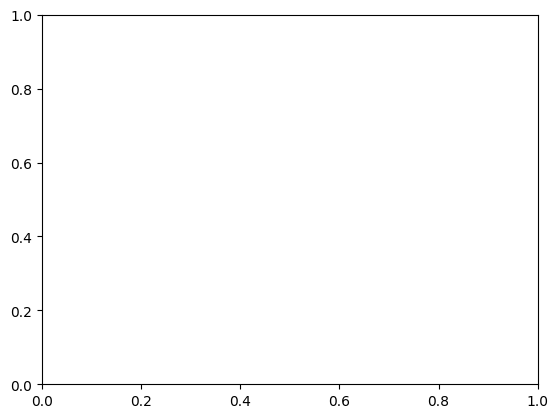

In [13]:
#  Graph solutions y(t):
fig, ax = plt.subplots()
plt.show()

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">


## Task 1b: Mass-Spring System with solve_ivp

Use `help(solve_ivp)` to learn more. One parameter is `t_span`, which allows you to add more time points to have the ODE solved for. Use this parameter and create a more data points, such that the resultant graph is smooth.

Redo graph with sufficient amount of data points, such that the graph looks continuous.
</div>

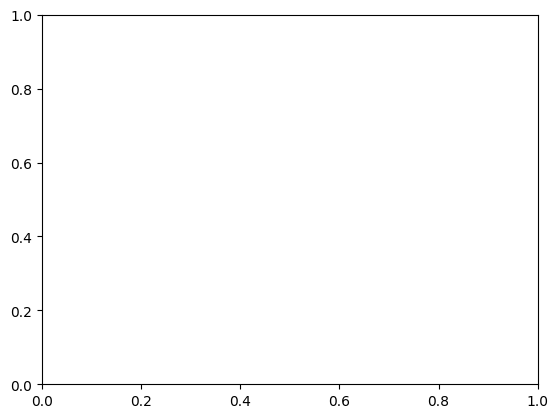

In [14]:
#  Redo `solve_ivp` and then graph solutions y(t): using `t_span` parameter to smoothen out.
fig, ax = plt.subplots()
plt.show()

## Stiff Problems

In general terms, stiffness can be measured as the ratio of the fastest over the slowest transient in a solution. Given the ODE $\dot{x} = Ax + f(t)$, the general solution is $x(t)=\sum_i A_i e^{-\lambda_i t} y_i + g(t)$ or the sum of transients plus a steady-state $g(t)$ solution for real positive $\lambda_i$. The stiffness $s$ is $s=\max(|\lambda_i|)/\min(|\lambda_i|)$

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">


## Task 2: Simple Pendulum

A slightly more interesting example is the simple pendulum. In this case, the differential equation is generally approximated for small angles. In that case, it can be solved analytically as it reduces to a harmonic oscillator. However, numerically, it is possible to solve the differential equation for arbitrary angles and compare it with realistic measurements.

Solve the following for $\theta(t)$:

$$
\frac{d^2 \theta}{dt^2} + \frac{g}{L} \sin \theta = 0
$$ 

Use $\theta_0=$ 40 degrees and initial speed is 0m/s.
</div>

In [9]:
# your code: #


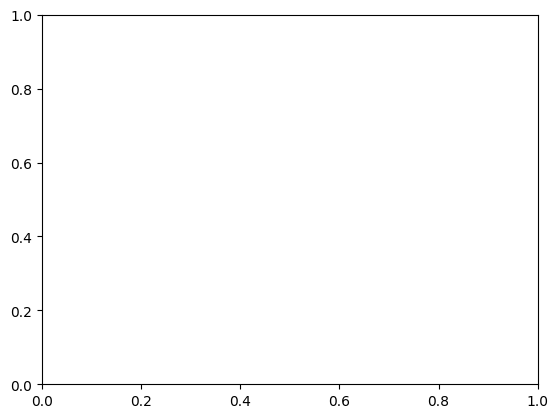

In [15]:
# make a graph of theta vs time.
fig, ax = plt.subplots()
plt.show()

## Runge-Kutta Method  

Runge-Kutta methods are more elaborate schemes than Euler's method using higher order terms and faster convergence. The most common variant is the fourth-order *Runge-Kutta* (RK4) method.

## Runge-Kutta 2nd and 3rd Order  

Given $\dot{y} = f(t, y)$, find $y(t)$ from $t_0$ to $t_f$:

1.  set $t_0, y_0$
2.  select $\Delta t = (t_f-t_0)/N$
2.  find $k_1 = \Delta t \cdot f(t_n, y_n)$
3.  find $k_2 = \Delta t \cdot f(t_n+\frac{1}{2}\Delta t, y_n + \frac{1}{2}k_1)$
4.  find $k_3 = \Delta t \cdot f(t_n + \Delta t, y_n + 2k_2-k_1 )$
4.  RK2: $y_{n+1} = y_n + k_2$ 
5.  RK3: $y_{n+1} = y_n + \frac{1}{6}(k_1 + 4k_2 + k_3)$ 
5.  if the difference between RK3 and RK2 exceeds tolerance, then redo with smaller $\Delta t$ value

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Task 3: Damped Oscillator

Solve the following ODE for $\theta(t)$:

$$
\ddot{\theta} = -\beta  \dot{\theta} - \gamma \sin(\theta)
$$

For $t=0$ s, use $\theta_0 = 45$ degrees and the speed is 0 m/s. Use $\beta = 0.5$ and $\gamma = 5$.
</div>

In [10]:
# your code: #


In [16]:
help(solve_ivp)

Help on function solve_ivp in module scipy.integrate._ivp.ivp:

solve_ivp(
    fun,
    t_span,
    y0,
    method='RK45',
    t_eval=None,
    dense_output=False,
    events=None,
    vectorized=False,
    args=None,
    **options
)
    Solve an initial value problem for a system of ODEs.

    This function numerically integrates a system of ordinary differential
    equations given an initial value::

        dy / dt = f(t, y)
        y(t0) = y0

    Here t is a 1-D independent variable (time), y(t) is an
    N-D vector-valued function (state), and an N-D
    vector-valued function f(t, y) determines the differential equations.
    The goal is to find y(t) approximately satisfying the differential
    equations, given an initial value y(t0)=y0.

    Some of the solvers support integration in the complex domain, but note
    that for stiff ODE solvers, the right-hand side must be
    complex-differentiable (satisfy Cauchy-Riemann equations [11]_).
    To solve a problem in the complex

## Discussion

Add any additional questions or comments.

The End.